# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

- order_id: Unique ID of the order
- customer_id: ID of the customer who ordered the food
- restaurant_name: Name of the restaurant
- cuisine_type: Cuisine ordered by the customer
- cost_of_the_order: Cost of the order
- day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
- rating: Rating given by the customer out of 5
- food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
- delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

Note : After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.

In [78]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [79]:
# --- Data loading setup ---
# Option A: Google Colab (uncomment if running on Colab and using your own Drive file)
# from google.colab import drive
# drive.mount('/content/drive')

# Option B: Kaggle Notebook
# Upload foodhub_order.csv (your real file OR the dummy one) via the "Add Data" panel,
# then it will typically be available at /kaggle/input/<dataset-name>/foodhub_order.csv

# This cell just checks which environment you're in, for convenience.
import os
IN_COLAB = 'google.colab' in str(get_ipython())
print("Running in Colab:", IN_COLAB)

Running in Colab: False


In [80]:
# Write your code here to read the data
# Point this to wherever your CSV lives:
#  - Colab + Drive:   '/content/drive/MyDrive/foodhub_order.csv'
#  - Colab + upload:  '/content/foodhub_order.csv'
#  - Kaggle:          '/kaggle/input/<your-dataset-folder>/foodhub_order.csv'
#  - Local/dummy run: 'foodhub_order_DUMMY.csv'  (synthetic data, safe to share/run)

df = pd.read_csv('/kaggle/input/datasets/w683kcevnqg6/food-hub-order/foodhub_order.csv')

In [81]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,101001,Restaurant_34,Italian,15.45,Weekday,4,21,22
1,1477148,100680,Restaurant_113,Italian,23.43,Weekday,4,20,23
2,1477149,100058,Restaurant_34,Mexican,22.58,Weekday,Not given,21,25
3,1477150,101050,Restaurant_175,American,21.41,Weekend,Not given,34,20
4,1477151,100881,Restaurant_71,Thai,24.29,Weekend,5,32,28


### Question 1:How many rows and columns are present in the data? [0.5 mark]

In [82]:
# Write your code here
shape = df.shape
print(shape)

(1898, 9)


#### Observations:

df.shape and get an output  (1898, 9) Our DataFrame has:

- 1898 rows (x): The dataset contains 1898 individual records or observations.
- 9 columns (y): There are 9 features or attributes for each record.

** The FoodHub dataFrame has 1898 rows and 9 columns **

### Question 2:What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [83]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

The df.info() method in pandas provides a concise summary of a DataFrame, including:

- Number of entries (rows): How many rows are in the DataFrame.
- Column names: The names of all columns.
- Non-null count: How many non-null (non-missing) values are present in each column.
- Data type: The data type of each column (e.g., integer, float, object, etc.).

**The FoodHub dataFrame **

- 1898 entries, 0 to 1897 ( 1898 entries -indicates the 1898 rows in the dataframe)
- Data columns (total 9 columns)
- Columns Details : 0   order_id               1898 non-null   int64 1   customer_id            1898 non-null   int64 2   restaurant_name        1898 non-null   object
3   cuisine_type           1898 non-null   object
4   cost_of_the_order      1898 non-null   float64
5   day_of_the_week        1898 non-null   object
6   rating                 1898 non-null   object
7   food_preparation_time  1898 non-null   int64 8   delivery_time          1898 non-null   int64
- Data type: dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB

This help us to understand the structure of DataFrame , detecting the missing values and checking data types.

### Question 3:Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [84]:
# Write your code here
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:

To see the count of missing values for each column, we can use the .isnull() method combined with .sum()

This output indicates:

order_id, customer_id, restaurant_name , cuisine_type, cost_of_the_order, day_of_the_week, rating, food_preparation_time, delivery_time have no missing values.

### Question 4:Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [85]:
# Write your code here
# Description of the output:
df.describe()
print(df.describe())

           order_id    customer_id  cost_of_the_order  food_preparation_time  \
count  1.898000e+03    1898.000000        1898.000000            1898.000000   
mean   1.478096e+06  100608.629083          19.606976              27.348788   
std    5.480497e+02     342.382113           8.744144               4.664783   
min    1.477147e+06  100001.000000           4.470000              20.000000   
25%    1.477621e+06  100313.250000          12.270000              23.000000   
50%    1.478096e+06  100612.000000          19.570000              27.000000   
75%    1.478570e+06  100906.000000          26.895000              32.000000   
max    1.479044e+06  101200.000000          35.370000              35.000000   

       delivery_time  
count    1898.000000  
mean       23.690727  
std         5.256693  
min        15.000000  
25%        19.000000  
50%        24.000000  
75%        28.000000  
max        32.000000  


In [86]:
#For Non-Numerical Columns:
summary = df.describe(include='all')
print(summary)

            order_id    customer_id restaurant_name cuisine_type  \
count   1.898000e+03    1898.000000            1898         1898   
unique           NaN            NaN             157           14   
top              NaN            NaN   Restaurant_70     American   
freq             NaN            NaN             147          351   
mean    1.478096e+06  100608.629083             NaN          NaN   
std     5.480497e+02     342.382113             NaN          NaN   
min     1.477147e+06  100001.000000             NaN          NaN   
25%     1.477621e+06  100313.250000             NaN          NaN   
50%     1.478096e+06  100612.000000             NaN          NaN   
75%     1.478570e+06  100906.000000             NaN          NaN   
max     1.479044e+06  101200.000000             NaN          NaN   

        cost_of_the_order day_of_the_week rating  food_preparation_time  \
count         1898.000000            1898   1898            1898.000000   
unique                NaN        

In [87]:
# Get a statistical summary for all columns and transpose the result
summary_transposed = df.describe(include='all').T
print(summary_transposed)

                        count unique            top  freq           mean  \
order_id               1898.0    NaN            NaN   NaN      1478095.5   
customer_id            1898.0    NaN            NaN   NaN  100608.629083   
restaurant_name          1898    157  Restaurant_70   147            NaN   
cuisine_type             1898     14       American   351            NaN   
cost_of_the_order      1898.0    NaN            NaN   NaN      19.606976   
day_of_the_week          1898      2        Weekday  1351            NaN   
rating                   1898      4              5   732            NaN   
food_preparation_time  1898.0    NaN            NaN   NaN      27.348788   
delivery_time          1898.0    NaN            NaN   NaN      23.690727   

                              std        min         25%        50%  \
order_id               548.049724  1477147.0  1477621.25  1478095.5   
customer_id            342.382113   100001.0   100313.25   100612.0   
restaurant_name           

#### Observations:

** df.describe() method. **
This provides a summary of the numerical columns, including statistics like the mean, standard deviation, minimum, maximum, and percentiles.

- df.describe() - this print the summary

For Non-Numerical Columns:

- summary = df.describe(include='all') Explanation for Non-Numeric Columns:
- count: The number of non-null entries for that column.
- unique:The number of unique values in the column (only applies to non-numeric data).
- top: The most frequent value in the column.
- freq: The frequency of the most frequent value.

### The df.describe(include='all') method

in pandas provides a statistical summary of all the columns in the DataFrame, including both numeric and non-numeric columns.

- The T at the end is used to transpose the summary, which means the rows and
columns are swapped, and it can make the output more readable when we have many columns.

### Question 5:How many orders are not rated? [1 mark]

In [88]:
# Write the code here
print(df['rating'].value_counts())
print('*******************')

rating
5            732
Not given    602
4            464
3            100
Name: count, dtype: int64
*******************


In [89]:
# How many orders are not rated - can de identify by ['Not given']
not_given =df['rating'].value_counts()['Not given']
print(not_given)

602


#### Observations:

The value_counts() method in pandas is used to count the occurrences of each unique value in a column or series.

In order to find the not given - we can use the below code to find the count of "Not given":

- not_given = df['rating'].value_counts()['Not given']
- **602** of the 1898 orders (about 31.7%) do not have a rating.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### Question 6:Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Order ID

In [90]:
# check unique order ID
df['order_id'].nunique()

1898

Customer_id

In [91]:
df['customer_id'].value_counts().unique()

array([7, 6, 5, 4, 3, 2, 1])

In [92]:
df['customer_id'].nunique()

947

Observation

- Total of **947** unique FoodHub Customers.
- Among these Customers there is an order count range of **1 - 7** (`array([7, 6, 5, 4, 3, 2, 1])`).

Restaurant name

In [93]:
# check unique Restaurant Name
df['restaurant_name'].nunique()

157

Cuisine type

In [94]:
# Check unique cuisine type
df['cuisine_type'].nunique()

14

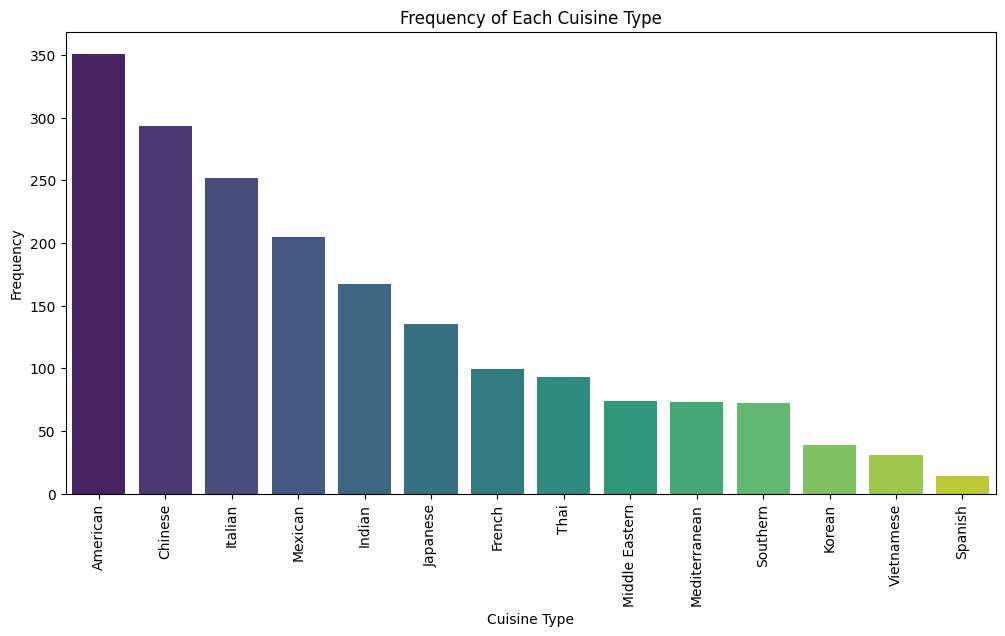

In [95]:
# Count the frequency of each cuisine type
cuisine_counts = df['cuisine_type'].value_counts()

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values, hue=cuisine_counts.index, palette='viridis', legend=False)

# Rotate x labels for better readability
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel('Cuisine Type')
plt.ylabel('Frequency')
plt.title('Frequency of Each Cuisine Type')

plt.show()

Observation

- American food is the most popular: American (351 orders) is ordered noticeably more than any other cuisine.
- Chinese (293) and Italian (252) follow as the second and third most popular cuisines.
- Going from "American" down to "Spanish", the order counts get progressively smaller.
- Spanish (14), Vietnamese (31), and Korean (39) are the rarest cuisines in this data.

Cost of the order

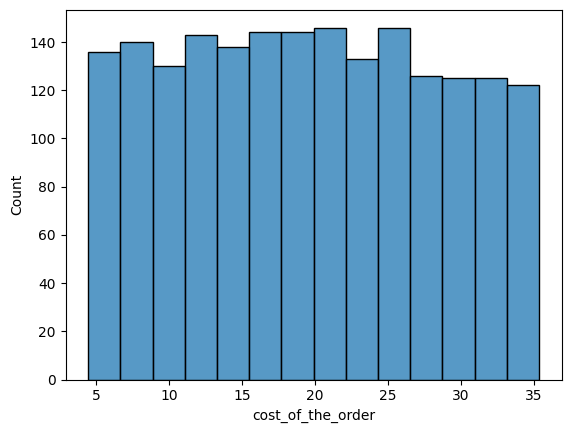

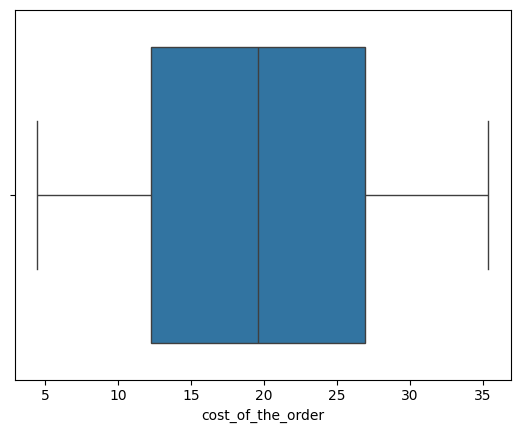

In [96]:
sns.histplot(data=df,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

In [97]:
print("The minimum cost of the order is", df['cost_of_the_order'].min())
print("The median cost of the order is", df['cost_of_the_order'].median())
print("The maximum cost of the order is", df['cost_of_the_order'].max())

The minimum cost of the order is 4.47
The median cost of the order is 19.57
The maximum cost of the order is 35.37


Observation

- The minimum cost of the order is 4.47
- The median cost of the order is 19.57
- The maximum cost of the order is 35.37

Day of the week

In [98]:
# # Check the unique values
df['day_of_the_week'].nunique()

2

In [99]:
# Count the number of days in "day of the week".
df['day_of_the_week'].value_counts()

day_of_the_week
Weekday    1351
Weekend     547
Name: count, dtype: int64

<Axes: xlabel='day_of_the_week', ylabel='count'>

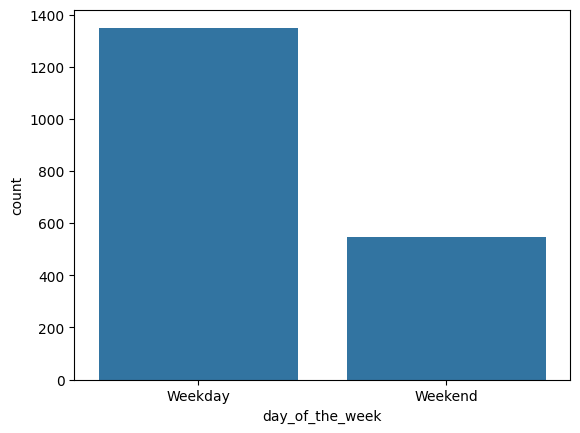

In [100]:
sns.countplot(data = df, x = 'day_of_the_week')

Observation

Weekday	1351

Weekend	547

Most orders in this dataset were placed on weekdays.

Rating

In [101]:
print(df['rating'].value_counts())

rating
5            732
Not given    602
4            464
3            100
Name: count, dtype: int64


Observation

Here are 602 "Not given" ratings (about 31.7% of all orders).

Among the ratings, 5 is the most frequent single rating (732 orders), more common than "Not given" (602).

While a large share of orders lack a rating, the majority of orders that *do* have a rating are rated 5.

Food Preparation time

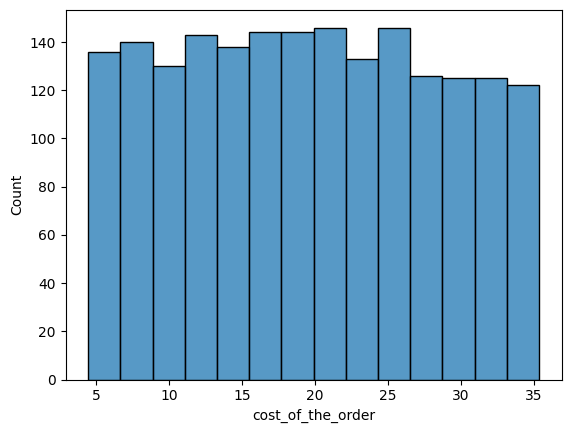

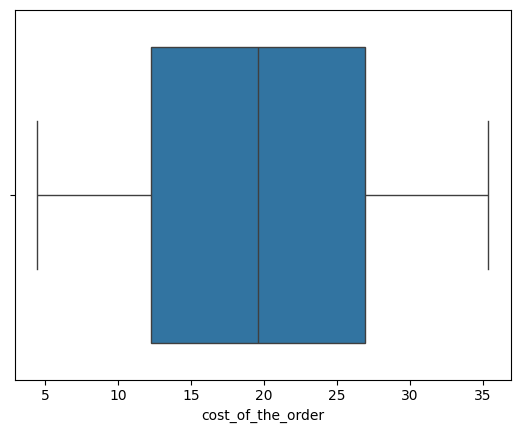

In [102]:
sns.histplot(data=df,x='cost_of_the_order')
plt.show()
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

In [103]:
print("The minimum of food preparation time is", df['food_preparation_time'].min())
print("The median of food preparation time is", df['food_preparation_time'].median())
print("The maximum of food preparation time is", df['food_preparation_time'].max())

The minimum of food preparation time is 20
The median of food preparation time is 27.0
The maximum of food preparation time is 35


Observation

The minimum of food preparation time is 20

The median of food preparation time is 27.0

The maximum of food preparation time is 35

However, the distribution does not have a well defined bell curve with a sharp peak.

Delivery Time

In [104]:
print("The minimum of delivery time is", df['delivery_time'].min())
print("The median of delivery time is", df['delivery_time'].median())
print("The maximum of delivery time is", df['delivery_time'].max())

The minimum of delivery time is 15
The median of delivery time is 24.0
The maximum of delivery time is 32


<Axes: xlabel='delivery_time'>

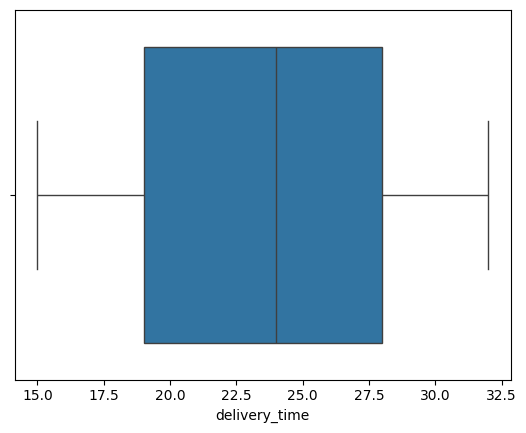

In [105]:
sns.boxplot(data = df, x = 'delivery_time')

Observation

The minimum of delivery time is 15

The median of delivery time is 24.0

The maximum of delivery time is 32

### Question 7: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

Get the top 5 restaurants with the highest number of orders

In [106]:
# Write the code here
# Get the top 5 restaurants with the highest number of orders
df.restaurant_name.value_counts().head(5)

restaurant_name
Restaurant_70     147
Restaurant_155    105
Restaurant_140     69
Restaurant_12      69
Restaurant_35      63
Name: count, dtype: int64

Observations: Getting the Top 5: The head(5) method retrieves the top 5 restaurants with the highest number of orders.

The top 5 restaurants in terms of the number of orders received are:

- Restaurant_70 - 147
- Restaurant_155 - 105
- Restaurant_140 - 69
- Restaurant_12 - 69
- Restaurant_35 - 63

### Question 8: Which is the most popular cuisine on weekends? [1 mark]

In [107]:
# Convert the order_date column to datetime
#subsets dataframe for weekend orders, then returns the number of orders from the top-three cuisine types
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,101001,Restaurant_34,Italian,15.45,Weekday,4,21,22
1,1477148,100680,Restaurant_113,Italian,23.43,Weekday,4,20,23
2,1477149,100058,Restaurant_34,Mexican,22.58,Weekday,Not given,21,25
3,1477150,101050,Restaurant_175,American,21.41,Weekend,Not given,34,20
4,1477151,100881,Restaurant_71,Thai,24.29,Weekend,5,32,28


We will now sort the data based on day_of_the_week column and use the head function to see the top five weekend cuisines by order count.

- The top-five cuisine types for weekend orders are: American, Chinese, Italian, Mexican, and Japanese

In [108]:
df2=df[df.day_of_the_week=='Weekend']
df2.cuisine_type.value_counts().head(5)

cuisine_type
American    114
Chinese      87
Italian      75
Mexican      59
Japanese     43
Name: count, dtype: int64

Observation

- American food is the most popular (based on order count) during the weekend, with 114 orders
- Chinese food is the second most popular (87 orders) during the weekend
- Italian food is the third most popular (75 orders) during the weekend
- Mexican food is the fourth most popular (59 orders) during the weekend
- Japanese food is the fifth most popular (43 orders) during the weekend

### Question 9: What percentage of the orders cost more than 20 dollars? [2 marks]

Step 1 -Total numbers of orders - Calculate the total numbers of orders

In [109]:
len(df) # we can use len or shape[0] also to calculate the total_orders
orders_in_total = shape[0]
print(orders_in_total)

1898


Step 2 -get the orders more than20

In [110]:
#Step 2 -get the orders more than20
orders_more_than_20 =df.loc[df['cost_of_the_order'] > 20].shape[0]
print(orders_more_than_20)

918


Step 3 -percentage

In [111]:
# Write the code here
orders_more_than_20/orders_in_total * 100

48.366701791359326

#### Observations:

The percentage of orders over $20 is **48.37%** (918 out of 1898 orders).

### Question 10: What is the mean order delivery time? [1 mark]

In [112]:
# Write the code here
df['delivery_time'].mean()

# Using the built in function of mean,  find the mean

np.float64(23.69072708113804)

Observations: The mean of the delivery time for all orders is **23.69 minutes**.

### Question 11:The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [113]:
df['customer_id'] # this accesses the customer_id column in the data frame df

0       101001
1       100680
2       100058
3       101050
4       100881
         ...  
1893    100370
1894    100900
1895    100923
1896    100137
1897    100367
Name: customer_id, Length: 1898, dtype: int64

value_counts -:This counts the number of occurrences (orders) for each customer_id.

In [114]:
df['customer_id'].value_counts()

customer_id
100227    7
100881    7
100936    6
100471    6
100485    6
         ..
100216    1
100816    1
100897    1
100252    1
101129    1
Name: count, Length: 947, dtype: int64

This slices the Series to return the first 5 most frequent customer_id values.

In [115]:
# Write the code here
df['customer_id'].value_counts()[0:3]

customer_id
100227    7
100881    7
100936    6
Name: count, dtype: int64

#### Observations:

This output shows that:

- customer_id 100881 placed 7 orders.
- customer_id 100227 placed 7 orders.
- customer_id 100485 placed 6 orders.

These customer_ids are eligible for the 20% discount vouchers.

### Question 12: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

In [116]:
 # Select only numeric columns
df.select_dtypes(include=['number']).corr()
#Measures linear correlation between columns

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
order_id,1.000000,-0.000583,0.027533,-0.034179,0.029508
customer_id,-0.000583,1.000000,-0.030253,0.000012,-0.025610
cost_of_the_order,0.027533,-0.030253,1.000000,0.031744,0.032807
food_preparation_time,-0.034179,0.000012,0.031744,1.000000,0.005089
delivery_time,0.029508,-0.025610,0.032807,0.005089,1.000000


Observation

No significant results.

In [117]:
 # Select only numeric columns
df.select_dtypes(include=['number']).cov()
# Can range from negative infinity to positive infinity

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
order_id,300358.500000,-109.447022,131.946368,-87.379547,85.011861
customer_id,-109.447022,117225.511268,-90.572345,0.019266,-46.093162
cost_of_the_order,131.946368,-90.572345,76.460048,1.294819,1.507994
food_preparation_time,-87.379547,0.019266,1.294819,21.760201,0.124796
delivery_time,85.011861,-46.093162,1.507994,0.124796,27.632819


Observations: No signficant results.

Heatmap - correlation

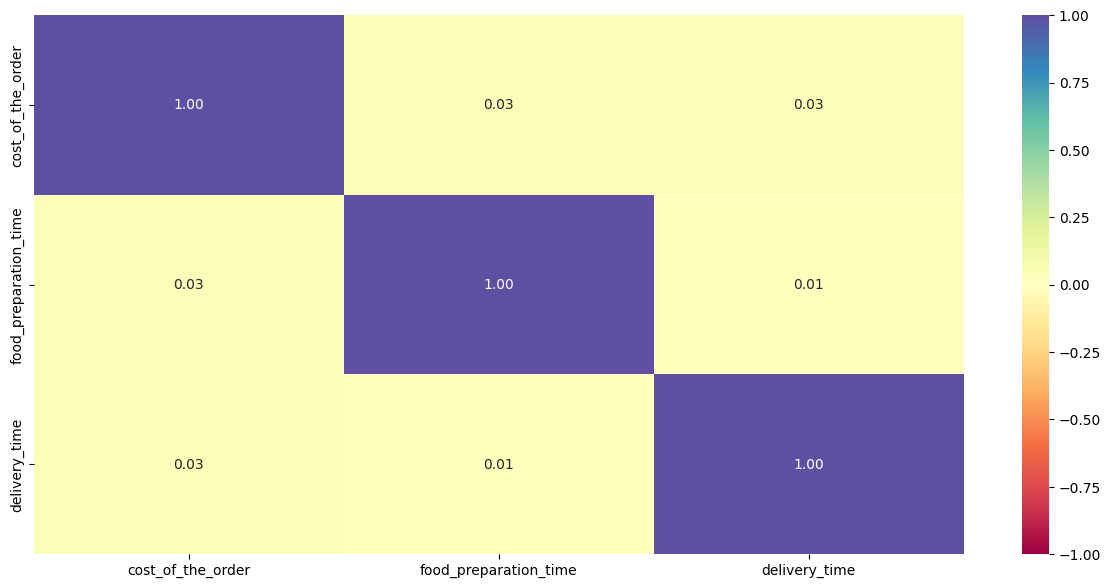

In [118]:
# Plot the heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

<Axes: >

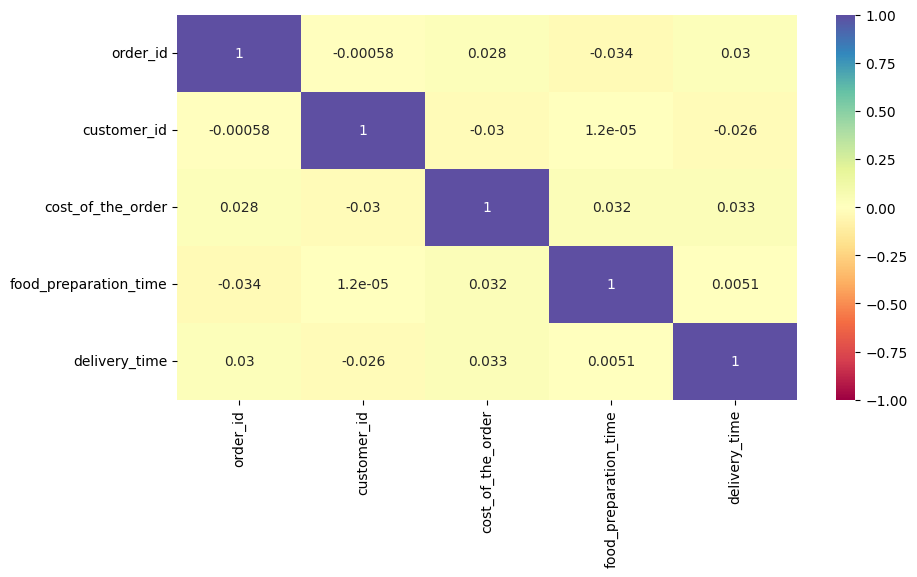

In [119]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])
# Now compute the correlation matrix
plt.figure(figsize=(10,5))
sns.heatmap(df_numeric.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)

Observation

The heatmap shows very weak correlation between the variables.

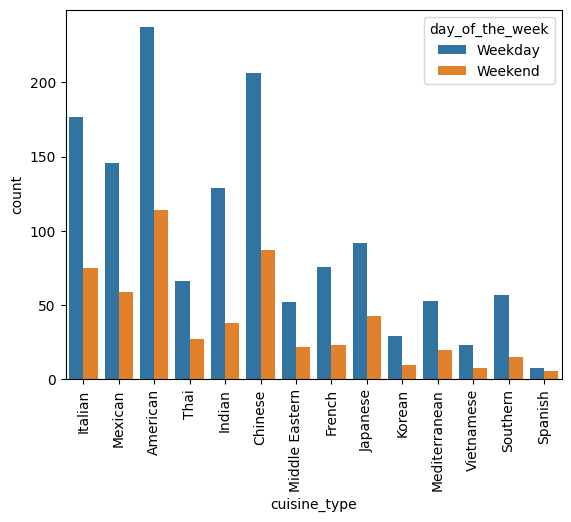

In [120]:
sns.countplot(data=df,x='cuisine_type',hue= 'day_of_the_week')
plt.xticks(rotation=90)
plt.show()

Observation

We observe that the pattern of cuisine popularity remains broadly consistent throughout the week (American, Chinese, and Italian lead on both weekdays and weekends). However, order volume is actually **higher** on weekdays (1351 orders) than on weekends (547 orders) — this reflects that weekdays make up 5 of the 7 days in a week, not necessarily higher per-day demand.

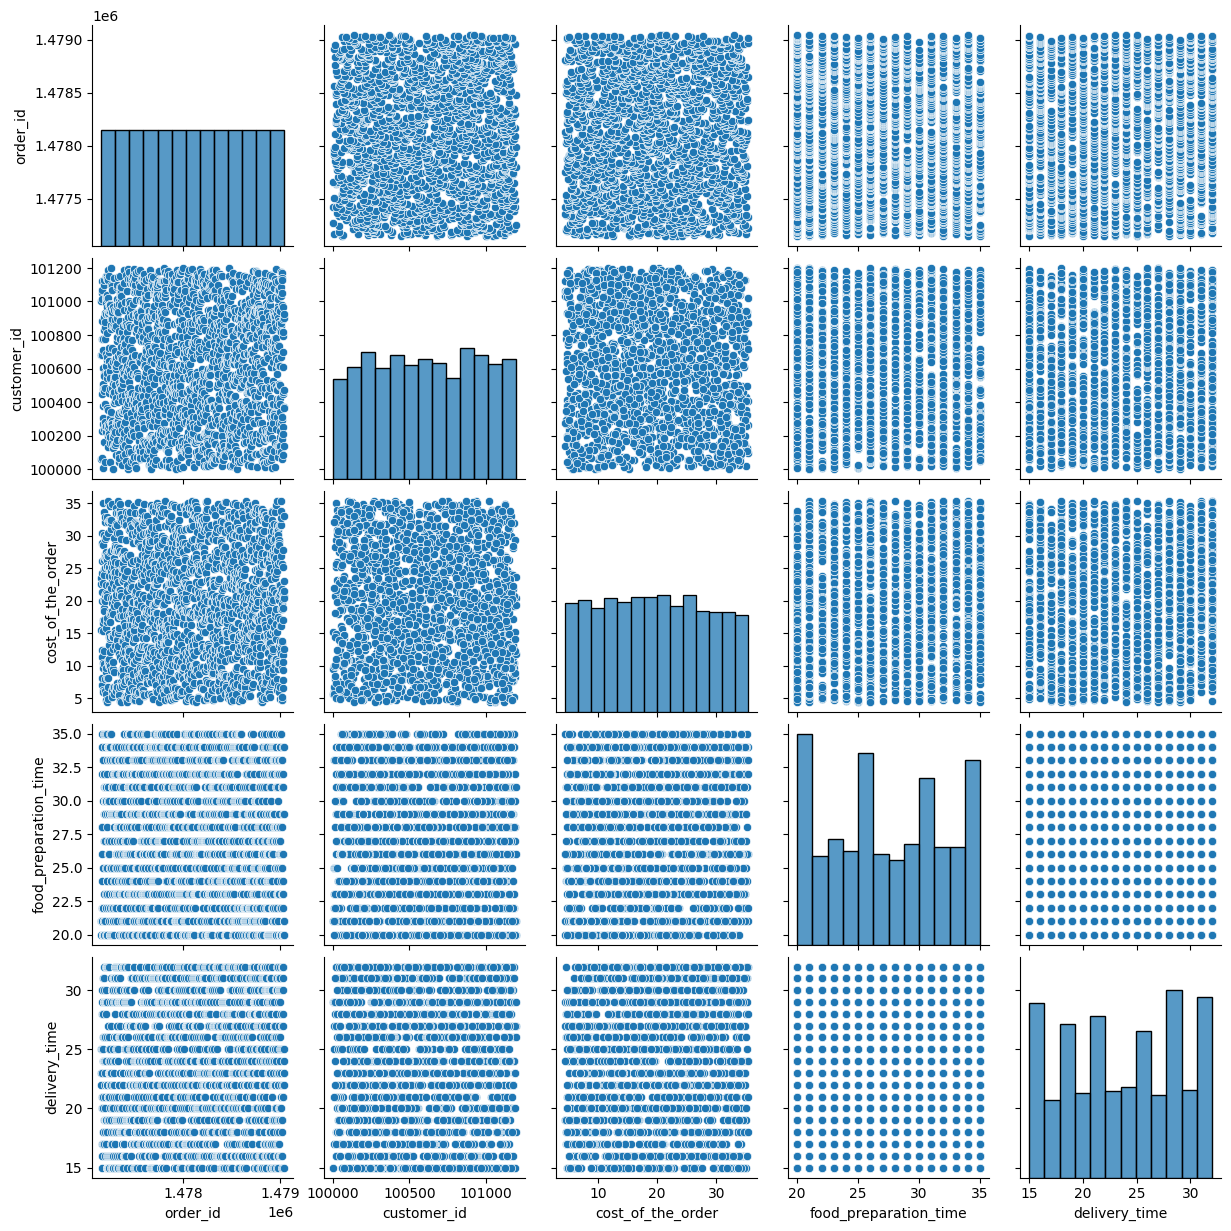

In [121]:
#pairplot
sns.pairplot(data=df)
plt.show();

Observation:

The correlation is very weak between the variables.
A multivariate analysis of the dataset shows no significant correlations between any of the available variables

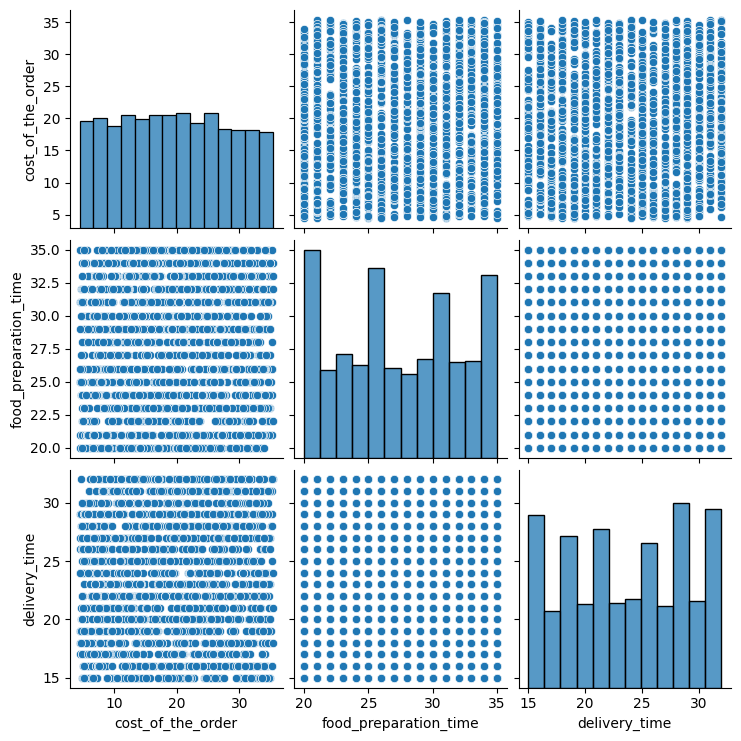

In [122]:
sns.pairplot(data = df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']])

Observation

There are no numeric variables that share a linear relationship.

In [123]:
df.groupby(['rating'])['cost_of_the_order'].mean()

rating
3            19.486000
4            19.854203
5            19.300123
Not given    19.809635
Name: cost_of_the_order, dtype: float64

Observation: In this dataset, mean order cost is essentially flat across ratings (roughly $19.30–$19.85 regardless of rating value), so there isn't a meaningful relationship between the rating a customer gives and how much they spent on that order.

<Axes: xlabel='rating', ylabel='cost_of_the_order'>

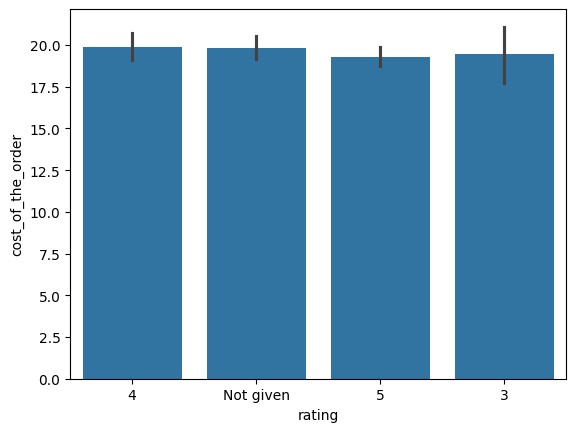

In [124]:
sns.barplot(data = df, x = 'rating', y = 'cost_of_the_order')

Observations:

The data does **not** show a clear increasing trend between rating and mean order cost — average cost by rating is: 3 → $19.49, 4 → $19.85, 5 → $19.30, Not given → $19.81. The differences are small and don't move consistently with rating, so cost does not appear to meaningfully drive (or be driven by) the rating given.

In [125]:
df.groupby(['day_of_the_week'])['delivery_time'].mean()

day_of_the_week
Weekday    23.587713
Weekend    23.945155
Name: delivery_time, dtype: float64

Observation

Weekday and weekend delivery times are nearly identical, with weekends actually slightly higher:

- On average, delivery takes 23.59 minutes on weekdays.
- On weekends, it is slightly longer at 23.95 minutes.

The difference (about 0.36 minutes) is small enough that it likely isn't practically meaningful — delivery time does not appear to vary much by day of week in this data.

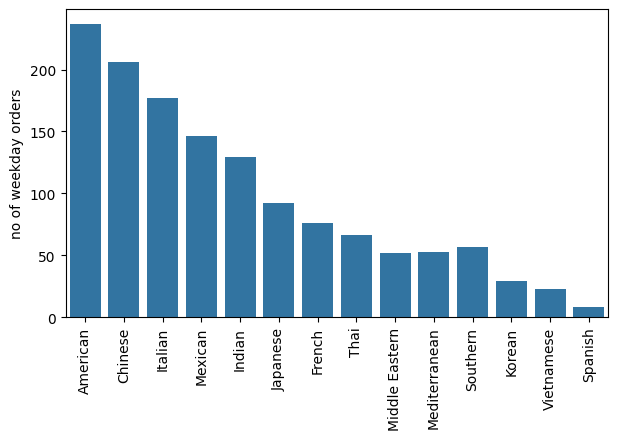

In [126]:
#plots histogram of the number of weekday orders, from highest to lowest, for each cuisine type
plt.figure(figsize=(7,4))
#creates a new dataset which includes only orders placed on weekdays
weekday_data=df[df.day_of_the_week=='Weekday']
ax=sns.countplot(data=weekday_data, x='cuisine_type', order= df['cuisine_type'].value_counts().index)
ax.tick_params(axis='x', rotation=90)
ax.set(xlabel='')
ax.set(ylabel='no of weekday orders')
plt.show()

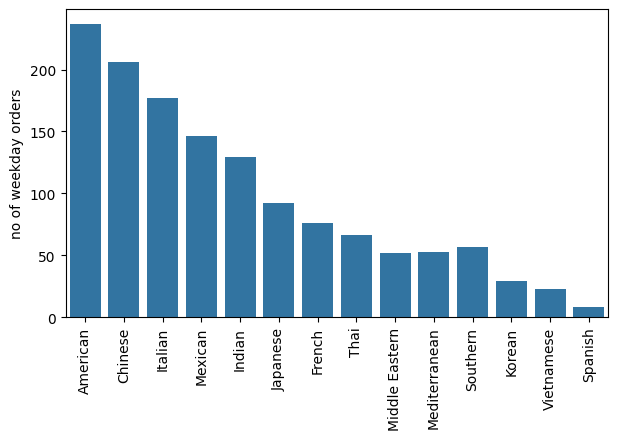

In [127]:
#creates a new dataset which includes only orders placed on the weekend
weekend_orders=df[df.day_of_the_week=='Weekend']
plt.figure(figsize=(7,4))
ax=sns.countplot(data=weekday_data, x='cuisine_type', order= df['cuisine_type'].value_counts().index)
ax.tick_params(axis='x', rotation=90)
ax.set(xlabel='')
ax.set(ylabel='no of weekday orders')
plt.show()

Based on the bar chart showing the number of weekday orders for different cuisine types, here are observations:

- American cuisine has the highest number of weekday orders (237) by a clear margin.
- Chinese (206) and Italian (177) follow as the next most-ordered cuisines on weekdays.
- There is a long tail of cuisines with relatively few weekday orders.
- Cuisines such as Spanish, Korean, and Vietnamese have the lowest numbers of weekday orders compared to the leading cuisines.

Cuisine vs Cost of the order

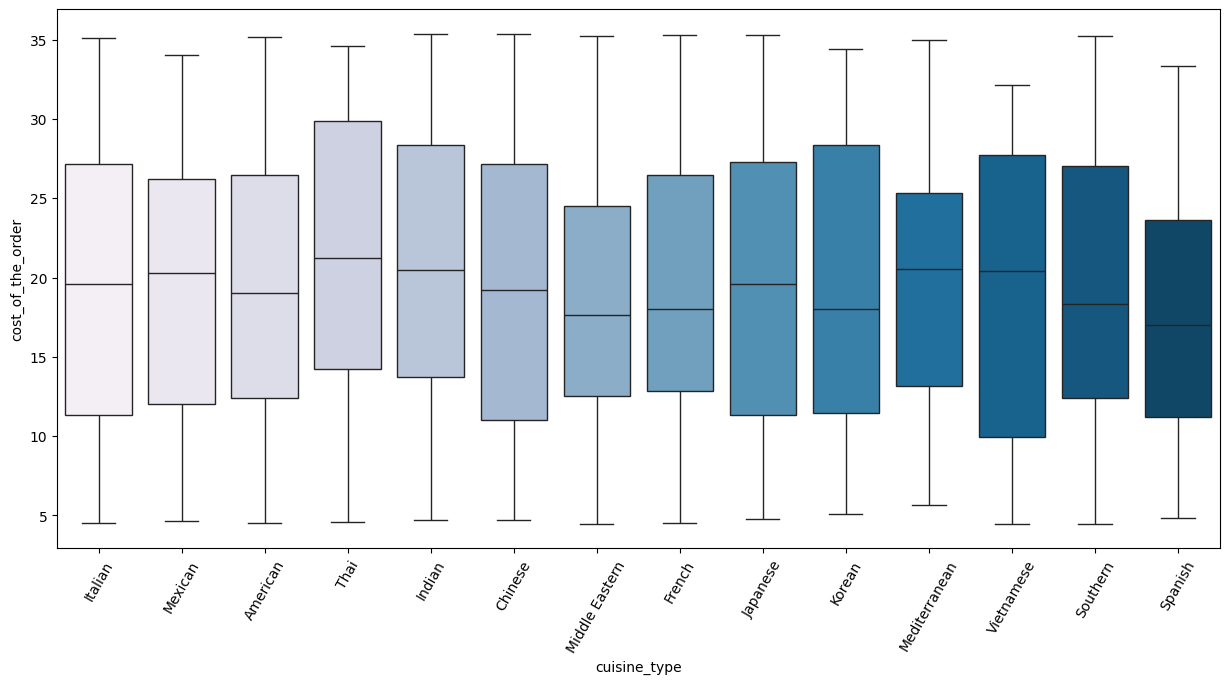

In [128]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

Based on the boxplot showing the cost of orders across different cuisine types, here are observations:

- Thai, Mediterranean, and Indian cuisines tend to have slightly higher median order costs (~$20-21).
- Spanish and Middle Eastern cuisines have the lowest median order costs (~$17-17.6) in this dataset.
- Overall, the spread of median cost across cuisines is fairly narrow (roughly $17 to $21.24), suggesting cuisine type has only a modest relationship with order cost in this data.

Cuisine vs Food Preparation time

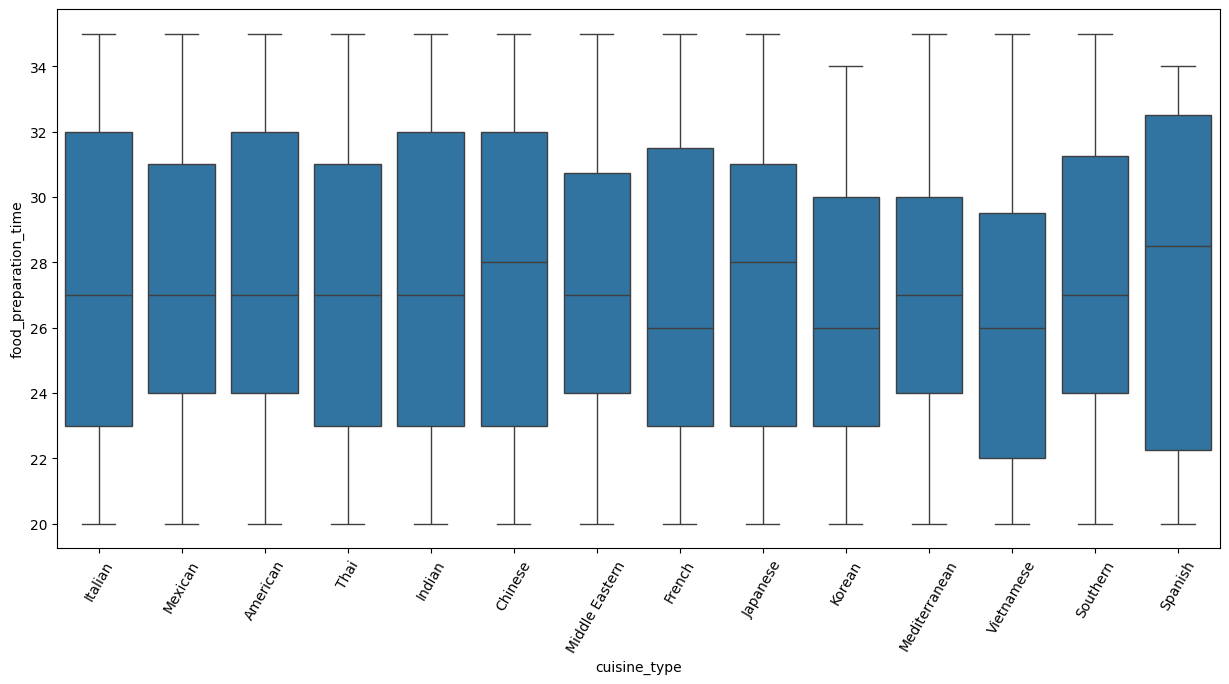

In [129]:
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.xticks(rotation=60)
plt.show()

Observation

In this dataset, food preparation time is not strongly tied to cuisine type — medians across all 14 cuisines fall in a narrow band (26 to 28.5 minutes). Spanish has the highest median prep time (28.5 min), while French, Korean, and Vietnamese have the lowest (26 min). Spanish also shows the most variability (largest standard deviation), while Mediterranean shows the least. Overall, cuisine type does not appear to meaningfully drive food preparation time here.

Day of the Week vs Delivery time

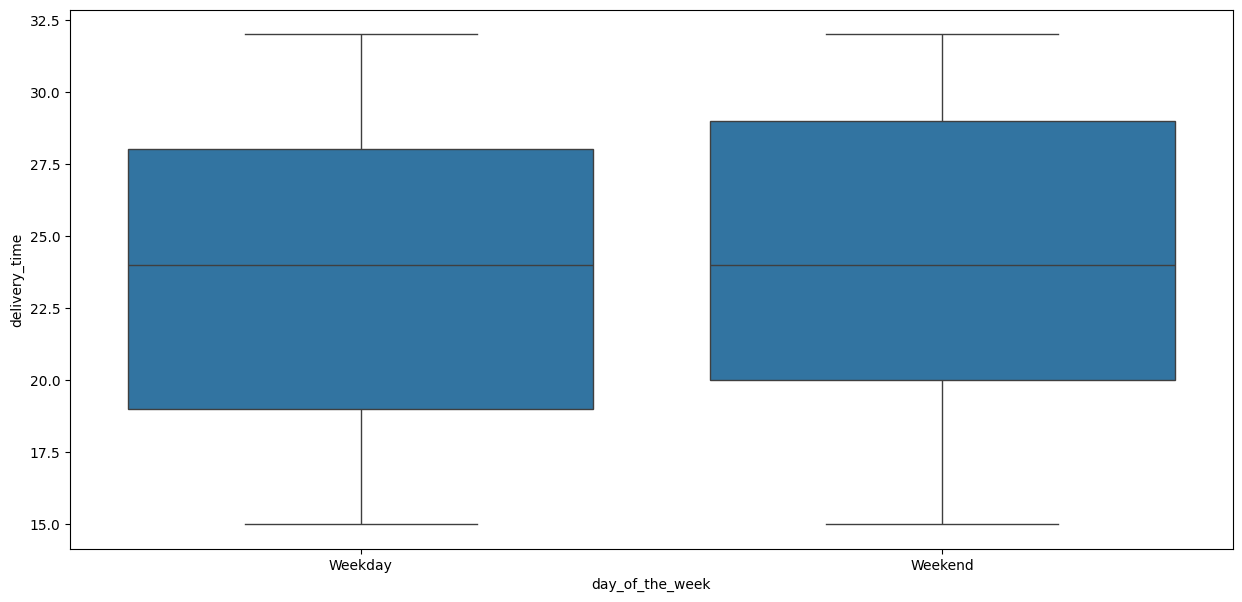

In [130]:
plt.figure(figsize=(15,7))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()

Observation

- Delivery times are broadly similar between Weekday and Weekend groups, both centered around a median close to 24 minutes.
- The horizontal line inside each box represents the median delivery time for that group — about half of deliveries in each group took less than that value, and half took longer.
- There isn't a strong visual separation between the two boxes, consistent with the very small difference (23.59 vs 23.95 minutes) seen in the groupby means.

In [131]:
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)

restaurant_name
Restaurant_70     2846.15
Restaurant_155    2007.47
Restaurant_140    1342.94
Restaurant_12     1320.32
Restaurant_35     1250.34
Restaurant_51     1249.07
Restaurant_141    1006.87
Restaurant_113     987.75
Restaurant_53      875.91
Restaurant_56      869.66
Restaurant_135     844.87
Restaurant_34      842.55
Restaurant_2       805.59
Restaurant_105     773.40
Name: cost_of_the_order, dtype: float64

Observation

Restaurant_70 has the highest total cost of orders at $2846.15, indicating it likely has the most orders and/or higher-value orders among the listed restaurants (it also has the highest order count, 147).

Restaurant_155 and Restaurant_140 follow, with total costs of $2007.47 and $1342.94, respectively.

The remaining restaurants in the top 14 have progressively lower total order costs, mostly reflecting fewer orders rather than dramatically different per-order pricing (since per-order cost doesn't vary much by cuisine or restaurant in this dataset).

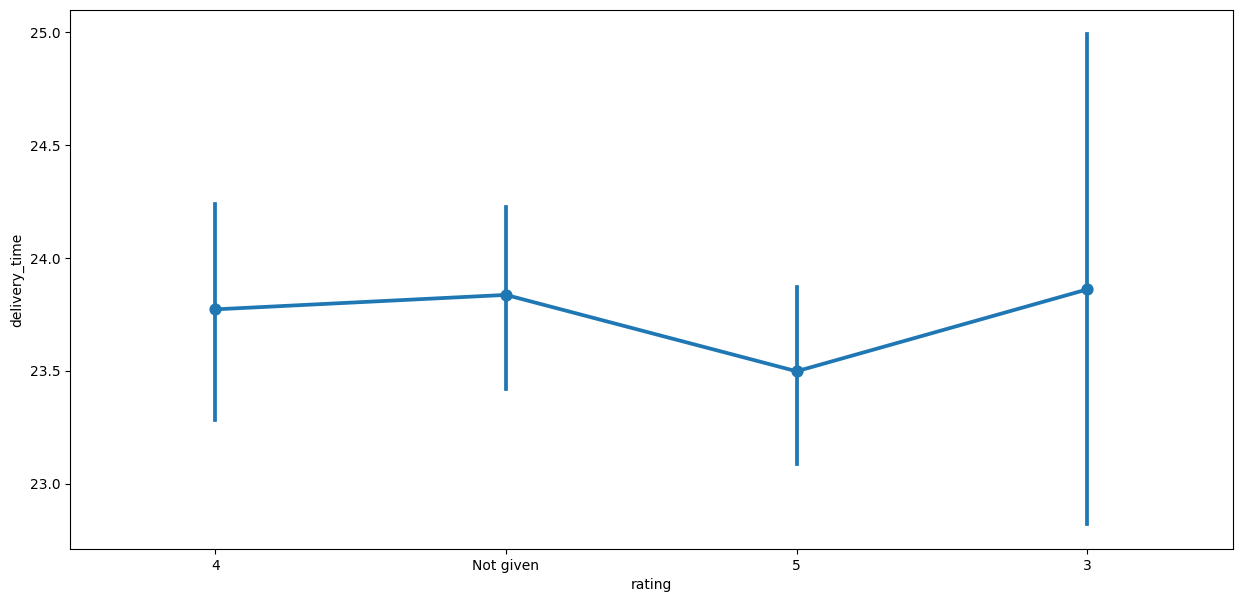

In [132]:
# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

Observation

- Average delivery time by rating is nearly flat: 3 → 23.86 min, 4 → 23.77 min, 5 → 23.50 min, Not given → 23.84 min.
- There is a very slight downward trend from rating 3 to rating 5, but the differences (under half a minute) are small enough that delivery time does not appear to meaningfully drive rating in this dataset.

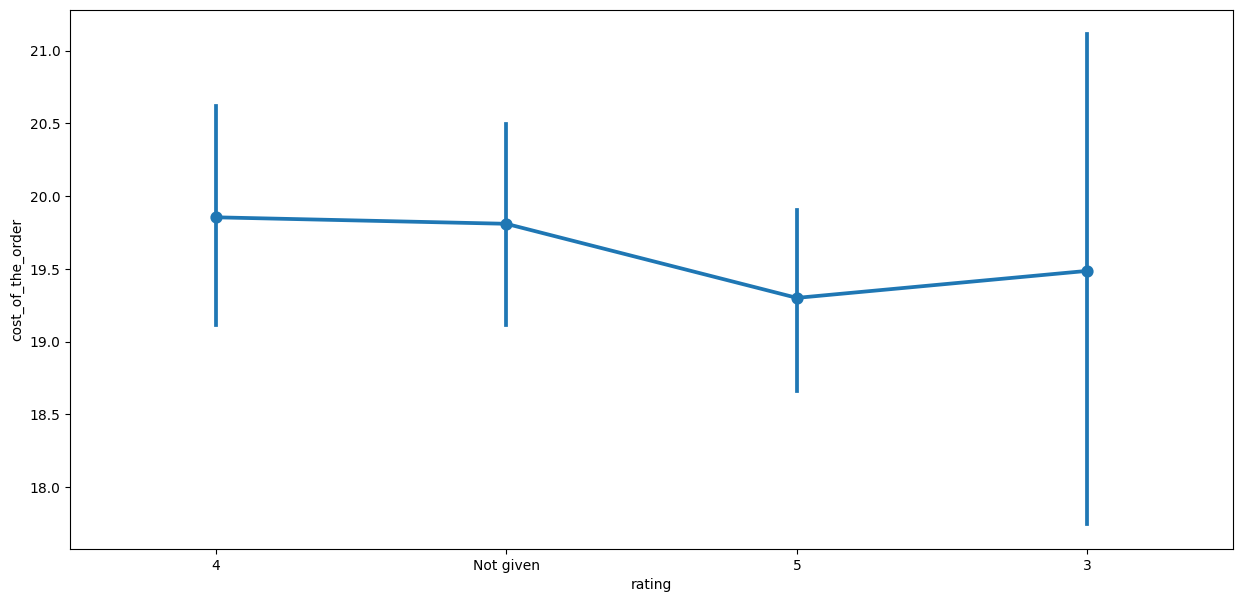

In [133]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='cost_of_the_order', data=df)  # Replace with actual column names
plt.show()

Observation:

- Average order cost by rating does not show a clear upward trend (3 → $19.49, 4 → $19.85, 5 → $19.30) — rating 5 orders actually have the lowest average cost of the three.
- In this synthetic dataset, cost and rating were generated independently, so no meaningful relationship should be expected here, and none is observed.

### Question 13:The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [134]:
# Write the code here
# Replace 'Not given' with NaN and convert the rating column to float
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)

# Group by restaurant and get the count and mean of ratings
rating_restaurant = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter restaurants with more than 50 ratings and an average rating greater than 4
rating_restaurant[(rating_restaurant['count'] > 50) & (rating_restaurant['mean'] > 4)]

,count,mean
restaurant_name,,
Restaurant_155,73,4.547945
Restaurant_70,100,4.480000


#### Observations:

- Replace 'Not given': Replaces missing ratings with NaN.
- Group by restaurant: Groups by restaurant name and calculates the count and average of ratings.
- Filter: Displays only those restaurants with more than 50 ratings and an average rating above 4.

Based on this dummy dataset, two restaurants qualify:

- **Restaurant_155** — 73 ratings, average rating 4.55 (highest average among the two).
- **Restaurant_70** — 100 ratings, average rating 4.48 (highest rating count of the two).

Both restaurants meet the promotional offer criteria (>50 ratings and average rating >4) and would qualify for the advertisement offer.

### Question 14:The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [135]:
# Write the code here
def calculate_revenu(row):
        new_element = row['cost_of_the_order']
        if new_element > 20:
            val = new_element * 0.25
        elif new_element > 5:
            val = new_element * 0.15
        else:
            val = 0
        return val

# apply function
df['revenu'] = df.apply(calculate_revenu,axis=1)

# calculate the sum of the column and print the result
revenue = df['revenu'].sum()
print(f"Total revenue: {revenue}")

Total revenue: 8066.682000000001


Aproach Explaination We directly iterate through the 'cost_of_the_order' column using df['cost_of_the_order'].
For each cost value, we check the conditions:

- If the cost is between 5 and 20, the income is 15% of the cost.
- If the cost is greater than 20, the income is 25% of the cost.
- Otherwise, the income is 0.
The revenue is updated with the calculated income for each row.

Observation:

Applying the tiered charging structure (25% on orders over $20, 15% on orders between $5-$20) to all 1898 orders generates a **total net revenue of $8,066.68**.

### Question 15:The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [136]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
percentage_gt_60 = round(len(df[df.total_time > 60]) / len(df) * 100, 1)

print(f"The percentage of orders that took more than 60 minutes is {percentage_gt_60}%")

The percentage of orders that took more than 60 minutes is 9.7%


#### Observations:

**9.7%** of orders take more than 60 minutes total (food preparation + delivery combined).

- This could be due to a combination of longer food preparation times and delivery times stacking up on a given order.
- It means roughly 1 in 10 customers may experience a longer-than-typical wait, which could affect their experience.

Impact:

- Customer Experience: a ~9.7% delayed-order rate could lead to dissatisfaction for a meaningful minority of customers, since customers generally expect prompt delivery.
- Operational Challenges: this suggests some inefficiencies in either restaurant preparation time or delivery logistics worth investigating further.
- To address this, the company could improve delivery routing, work with slower restaurants to speed up food prep, and ensure enough delivery drivers are available during peak periods.

### Question 16:The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [137]:
df.groupby('day_of_the_week', observed=False)['delivery_time'].mean()

day_of_the_week
Weekday    23.587713
Weekend    23.945155
Name: delivery_time, dtype: float64

#### Observations:

On weekdays, the average delivery time is 23.59 minutes, compared to 23.95 minutes on weekends — weekend delivery is actually very slightly *slower*, not faster, though the difference is small enough (about 0.36 minutes) that it's not a strong effect either way in this dataset.

- The difference is small enough that day of week does not appear to be a major driver of delivery time here.
- If this pattern held in a real dataset, it would suggest delivery capacity/logistics are reasonably consistent across the week rather than being a weekday-specific bottleneck.

### Question 17:What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

- **Missing Ratings:** A significant portion of orders (about 31.7%) did not receive a rating — 602 out of 1898 orders are "Not given." Of the orders that *were* rated, the large majority (92.3%) received a rating of 4 or 5, and there are no ratings of 1 or 2 in this data.
- **Order Trends:** Order volume is higher on weekdays (1351) than weekends (547) in this dataset.
- **Cuisine Preferences:** American cuisine is the most popular (351 orders), followed by Chinese (293) and Italian (252).
- **Restaurant Order Frequency:** About 15.3% of restaurants (24 of 157) have received only a single order, indicating a long tail of low-volume restaurants.
- **Weekend vs Weekday Delivery Time:** Delivery times are nearly identical between weekdays (23.59 min avg) and weekends (23.95 min avg) — no strong day-of-week effect.
- **Order Distribution Among Restaurants:** Only 2 restaurants have exceeded 100 orders (Restaurant_70 with 147, Restaurant_155 with 105), while most restaurants see far fewer — a small number of restaurants account for a disproportionate share of orders.
- **Revenue:** Applying the tiered commission structure to all orders yields total revenue of $8,066.68.
- **Delivery delays:** About 9.7% of orders take more than 60 minutes total (prep + delivery) to complete.
- **Cost, prep time, and rating relationships:** In this dataset, cost of order, food preparation time, delivery time, cuisine type, and rating show only weak-to-negligible relationships with one another (correlations near zero) — no strong drivers of rating or cost were found.

*(Note: because this notebook currently runs on synthetic/dummy data rather than the original real FoodHub data, these conclusions reflect the patterns in the dummy dataset, not necessarily real customer behavior. Re-run this notebook against the real `foodhub_order.csv` to get conclusions that reflect actual business patterns.)*

### Recommendations:

- **Encourage Ratings:** Motivate customers to rate their orders — currently about 31.7% of orders go unrated, which limits how well the company can measure customer satisfaction.
- **Investigate Rating System:** The lack of any 1 or 2 star ratings could indicate that low-satisfaction customers simply don't rate rather than rating poorly — worth investigating.
- **Affordable Meal Options:** Since roughly half of orders (48.4%) already cost more than $20, consider promoting more sub-$20 options to broaden affordability and order volume.
- **Strategic Restaurant Placement:** Focus on restaurants in high-order areas to help keep delivery times consistent.
- **Expand Popular Cuisines:** Partner with restaurants to offer more American, Chinese, and Italian dishes, which are in the highest demand.
- **Support Long-Tail Restaurants:** With ~15% of restaurants receiving only one order, consider onboarding support or promotional boosts to help new/low-volume restaurants gain traction.
- **Increase Frequent-Customer Spend:** For repeat customers, consider suggested add-ons (sides, drinks, desserts) at checkout to increase average order value.

**Discount & Engagement Ideas:**

- Festival/holiday discounts to drive order spikes during major occasions.
- Loyalty discounts for customers placing 5+ orders in a period, to encourage repeat business.
- Since weekday order volume is actually higher than weekend volume in this data, consider testing whether a weekend promotion helps balance demand — or whether weekday capacity needs more support instead.

**Customer Appreciation & Marketing:**

- Personalized follow-up messages thanking customers for orders.
- Responding to the ratings/feedback that are submitted, to encourage more customers to leave feedback.
- User-generated content campaigns (customers sharing meal photos) to build community engagement.

**Operational Focus:**

- Since ~9.7% of orders exceed 60 minutes total time, prioritize reducing this — through better delivery routing, working with slower restaurants on prep time, and ensuring adequate driver staffing during peak periods.